# Diabetes Prediction   

Team:
- Brandon Cabrera

Course: CISD 43 Spring 2026


Project Description:
Project involves analyzing a diabetes dataset which has key indicators for diagonising the medical condition. The goal is to be able to train a model to accuarately predict whether the individual has diabetes

In [14]:
#Import neccesary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

 install dependencies if you want to follow along: 
!pip install pandas numpy matplotlib seaborn scikit-learn

if you have uv you can run uv sync and then activate your virtual enviroment


# Approach 

Predicting whether someone has diabetes or not is going to be a classification problem. So I will use a KNN Classifier model in order to get this done. First I will clean the data if need be, make some visualzations to see if there are some patterns worth noting, and finally work on making an accurate model. 

# EDA

In [15]:
diabetes_data = pd.read_csv("data/diabetes.csv")
diabetes_data.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Thankfully, the features are all numerical so we don't have to worry about encoding any categories. Let's check for any missing values.


In [16]:
diabetes_data.info()


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [44]:
diabetes_data.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

The dataset is clean so now to do some visualzations. 

In [45]:
#Code modified from an old project
def plot_boxplot_stats(x:str) -> pd.DataFrame: 
  """Plots a boxplot and returns a DataFrame containing descriptive stats shown by the boxplot

  Args:
      x (String): A column name from diabetes_data
      y (String)): A column name from diabetes_data

  Returns:
      DataFrame: Contains descriptive stats of what is shown on the boxplot
  """
  sns.boxplot(data = diabetes_data, x = x,hue ='Outcome')
  plt.show()
  group_0 = diabetes_data[diabetes_data['Outcome'] == 0][x]
  group_1 = diabetes_data[diabetes_data['Outcome'] == 1][x]
  group_combined = pd.DataFrame({'No Diabetes' : group_0.describe(), 'With Diabetes': group_1.describe()})
  return group_combined

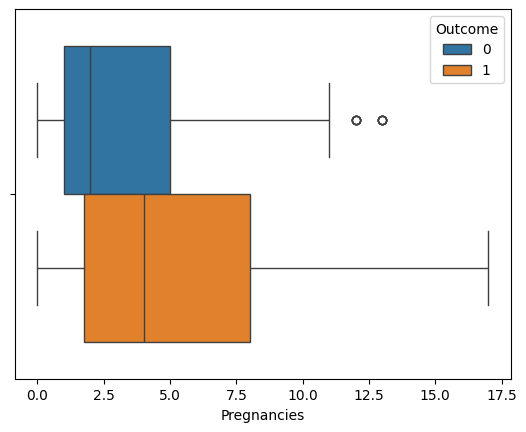

,No Diabetes,With Diabetes
count,500.000000,268.000000
mean,3.298000,4.865672
std,3.017185,3.741239
min,0.000000,0.000000
25%,1.000000,1.750000
50%,2.000000,4.000000
75%,5.000000,8.000000
max,13.000000,17.000000


In [46]:
pregnancies_groups = plot_boxplot_stats('Pregnancies')
pregnancies_groups

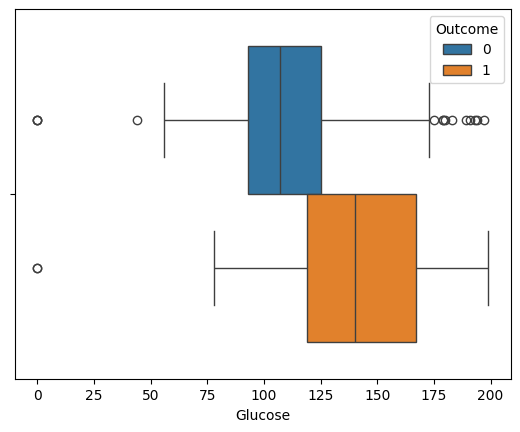

,No Diabetes,With Diabetes
count,500.0000,268.000000
mean,109.9800,141.257463
std,26.1412,31.939622
min,0.0000,0.000000
25%,93.0000,119.000000
50%,107.0000,140.000000
75%,125.0000,167.000000
max,197.0000,199.000000


In [47]:
glucose_groups = plot_boxplot_stats('Glucose')
glucose_groups

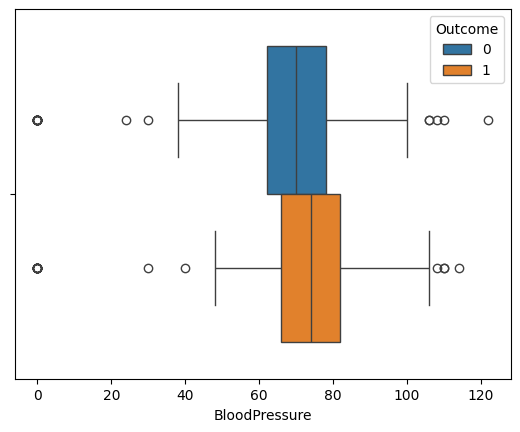

,No Diabetes,With Diabetes
count,500.000000,268.000000
mean,68.184000,70.824627
std,18.063075,21.491812
min,0.000000,0.000000
25%,62.000000,66.000000
50%,70.000000,74.000000
75%,78.000000,82.000000
max,122.000000,114.000000


In [48]:
blood_pressure_groups = plot_boxplot_stats('BloodPressure')
blood_pressure_groups

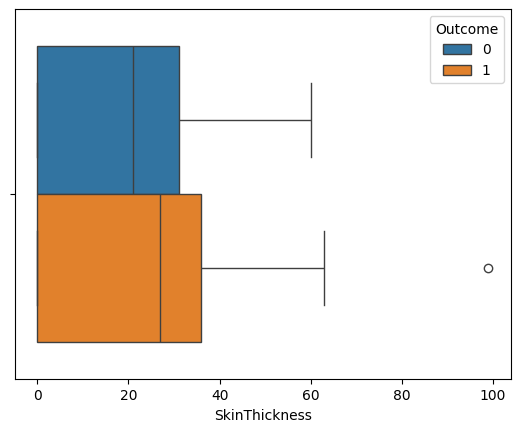

,No Diabetes,With Diabetes
count,500.000000,268.000000
mean,19.664000,22.164179
std,14.889947,17.679711
min,0.000000,0.000000
25%,0.000000,0.000000
50%,21.000000,27.000000
75%,31.000000,36.000000
max,60.000000,99.000000


In [49]:
skin_thickness_groups = plot_boxplot_stats('SkinThickness')
skin_thickness_groups

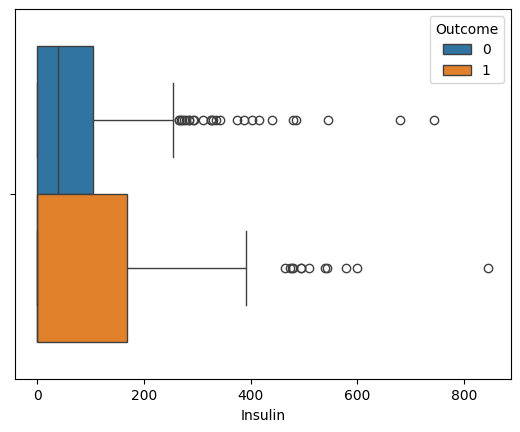

,No Diabetes,With Diabetes
count,500.000000,268.000000
mean,68.792000,100.335821
std,98.865289,138.689125
min,0.000000,0.000000
25%,0.000000,0.000000
50%,39.000000,0.000000
75%,105.000000,167.250000
max,744.000000,846.000000


In [50]:
insulin_groups = plot_boxplot_stats('Insulin')
insulin_groups

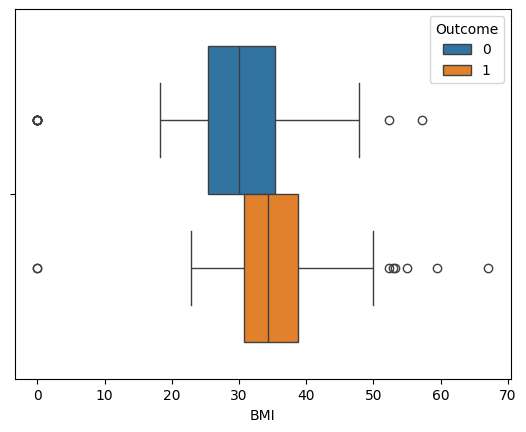

,No Diabetes,With Diabetes
count,500.000000,268.000000
mean,30.304200,35.142537
std,7.689855,7.262967
min,0.000000,0.000000
25%,25.400000,30.800000
50%,30.050000,34.250000
75%,35.300000,38.775000
max,57.300000,67.100000


In [51]:
bmi_groups = plot_boxplot_stats('BMI')
bmi_groups

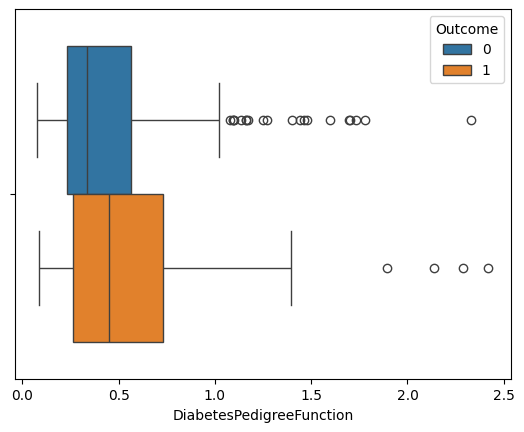

,No Diabetes,With Diabetes
count,500.000000,268.000000
mean,0.429734,0.550500
std,0.299085,0.372354
min,0.078000,0.088000
25%,0.229750,0.262500
50%,0.336000,0.449000
75%,0.561750,0.728000
max,2.329000,2.420000


In [52]:
diabetes_pedigree_function_groups = plot_boxplot_stats('DiabetesPedigreeFunction')
diabetes_pedigree_function_groups

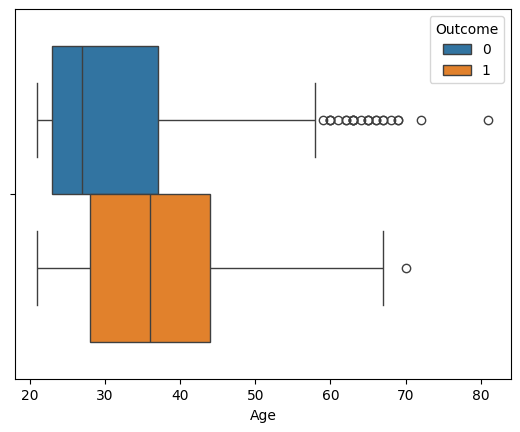

,No Diabetes,With Diabetes
count,500.000000,268.000000
mean,31.190000,37.067164
std,11.667655,10.968254
min,21.000000,21.000000
25%,23.000000,28.000000
50%,27.000000,36.000000
75%,37.000000,44.000000
max,81.000000,70.000000


In [53]:
age_groups = plot_boxplot_stats('Age')
age_groups